In [1]:
import os
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from glob import glob
from tslearn import barycenters
from scipy.stats import wasserstein_distance
from scipy.signal import detrend
import os.path as op

from kNN_divergence import *

# Add rpy2
%load_ext rpy2.ipython

In [2]:
%%R 

suppressPackageStartupMessages({
    library(broom)
    library(cowplot)
    library(ggpubr)
    library(ggsignif)
    library(glue)
    library(patchwork)
    library(rlist)
    library(see)
    library(tidyverse)
})


# Set cowplot theme
theme_set(theme_cowplot())

Error in library(ggpubr) : there is no package called ‘ggpubr’


RInterpreterError: Failed to parse and evaluate line '\nsuppressPackageStartupMessages({\n    library(broom)\n    library(cowplot)\n    library(ggpubr)\n    library(ggsignif)\n    library(glue)\n    library(patchwork)\n    library(rlist)\n    library(see)\n    library(tidyverse)\n})\n\n\n# Set cowplot theme\ntheme_set(theme_cowplot())\n'.
R error message: 'Error in library(ggpubr) : there is no package called ‘ggpubr’'

In [8]:
# Define base_repo as one level up from current directory
base_repo = op.dirname(op.abspath(''))
plot_dir = f"{base_repo}/data_visualization/plots/"

# load pyspi SPI info
pyspi_SPI_info = pd.read_csv(f"{base_repo}/functional_connectivity_analysis/pyspi_SPI_info.csv")

# Initialize list for pyspi results
all_pyspi_barycenter_res_averaged_epochs_list = []

# Load pyspi results 
functional_connectivity_measures_dir = f"{base_repo}/data/empirical/functional_connectivity_measures/"
MEG_time_series_dir = f"{base_repo}/data/empirical/MEG_time_series/"
model_sims_dir = f"{base_repo}/data/model/simulated_data/"
model_barycenter_dir = f'{base_repo}/data/model/barycenter_results/'

# Load in pyspi results
# for pyspi_res_file in os.listdir(pyspi_res_path_averaged):
for pyspi_barycenter_res_file in glob(f"{functional_connectivity_measures_dir}/*barycenter_sq*.csv"):
    # Filter to rows where SPI contains the substring 'barycenter'
    pyspi_barycenter_res_averaged = pd.read_csv(pyspi_barycenter_res_file).query("SPI.str.contains('bary')", engine='python')
    all_pyspi_barycenter_res_averaged_epochs_list.append(pyspi_barycenter_res_averaged)

# Specifically filter to bary_euclidean
all_pyspi_barycenter_res_averaged_epochs = pd.concat(all_pyspi_barycenter_res_averaged_epochs_list)

# Separate SPI by whether it ends with _max or _max_time
all_pyspi_barycenter_res_averaged_epochs['SPI_stat'] = np.where(all_pyspi_barycenter_res_averaged_epochs['SPI'].str.contains('_max_time'), 'max_time', 'max')
all_pyspi_barycenter_res_averaged_epochs['SPI'] = all_pyspi_barycenter_res_averaged_epochs['SPI'].str.replace('_max_time', '').str.replace('_max', '')

bary_sq_euclidean_res_averaged_epochs = (all_pyspi_barycenter_res_averaged_epochs
                                         .query("SPI=='bary-sq_euclidean' & relevance_type != 'Relevant target'")
                                         )

# Empirical data
bary_sq_euclidean_res_averaged_epochs = (bary_sq_euclidean_res_averaged_epochs
    .pivot(index=['SPI', 'meta_ROI_from', 'meta_ROI_to', 'Data_Type', 'stimulus_type', 'relevance_type', 'subject_ID', 'stimulus_presentation'],
                                                    columns='SPI_stat', values='value')
    .reset_index()
    .query("meta_ROI_from == 'Category_Selective' & meta_ROI_to in ['Prefrontal_Cortex', 'V1_V2']")
    .assign(Model = lambda x: np.where(x['meta_ROI_to'] == 'Prefrontal_Cortex', 'GNWT', 'IIT'))
    .drop(columns=['meta_ROI_from', 'meta_ROI_to'])
)

# One for raw, one for abs
bary_sq_euclidean_res_averaged_epochs_raw = bary_sq_euclidean_res_averaged_epochs.query("Data_Type=='Raw'")
bary_sq_euclidean_res_averaged_epochs_abs = bary_sq_euclidean_res_averaged_epochs.query("Data_Type=='Abs'")


In [9]:
N_sims = 1000
noise_level = 1.0
n_params_IIT = 18
n_params_GNWT = 22

GNWT_stim_on_pyspi_barycenter_res = pd.read_csv(f"{model_barycenter_dir}/GNWT_stim_on_sims_all_pyspi_barycenter_sq_euclidean_results_noise_{noise_level}_params_{n_params_GNWT}.csv")
GNWT_stim_off_pyspi_barycenter_res = pd.read_csv(f"{model_barycenter_dir}/GNWT_stim_off_sims_all_pyspi_barycenter_sq_euclidean_results_noise_{noise_level}_params_{n_params_GNWT}.csv")
IIT_stim_on_pyspi_barycenter_res = pd.read_csv(f"{model_barycenter_dir}/IIT_stim_on_sims_all_pyspi_barycenter_sq_euclidean_results_noise_{noise_level}_params_{n_params_IIT}.csv")
IIT_stim_off_pyspi_barycenter_res = pd.read_csv(f"{model_barycenter_dir}/IIT_stim_off_sims_all_pyspi_barycenter_sq_euclidean_results_noise_{noise_level}_params_{n_params_IIT}.csv")

all_model_pyspi_res = (pd.concat([GNWT_stim_on_pyspi_barycenter_res,
                                    GNWT_stim_off_pyspi_barycenter_res,
                                    IIT_stim_on_pyspi_barycenter_res,
                                    IIT_stim_off_pyspi_barycenter_res])
                        .query("meta_ROI_from == 'Category_Selective' & SPI in ['bary-sq_euclidean_max', 'bary-sq_euclidean_max_time']")
                        .assign(SPI_stat = lambda x: np.where(x['SPI'].str.contains('_max_time'), 'max_time', 'max'),
                                SPI = lambda x: x['SPI'].str.replace('_max_time', '').str.replace('_max', ''),
                                Model = lambda x: x['sim_context'].str.split('_stim').str[0],
                                stimulus_presentation = lambda x: x['sim_context'].str.split('stim_').str[1])
                        .drop(columns=['sim_context'])
)

# Add noise column if it doesn't exist
if 'Noise' not in all_model_pyspi_res.columns:
    all_model_pyspi_res['Noise'] = noise_level


# Filter to bary-sq_euclidean
all_model_pyspi_res_bary_sq_euclidean = (all_model_pyspi_res
                                         .query("SPI=='bary-sq_euclidean'")
                                         .pivot(index=['SPI', 'Noise', 'meta_ROI_from', 'meta_ROI_to', 'Data_Type', 'sim_num', 'param_number', 'Model', 'stimulus_presentation'],
                                                    columns='SPI_stat', values='value')
                                        .reset_index()
                                        .drop(columns=['meta_ROI_from', 'meta_ROI_to'])
)

all_model_pyspi_res_bary_sq_euclidean_raw = all_model_pyspi_res_bary_sq_euclidean.query("Data_Type=='Raw'")
all_model_pyspi_res_bary_sq_euclidean_abs = all_model_pyspi_res_bary_sq_euclidean.query("Data_Type=='Abs'")

In [10]:
all_raw_data_for_comparison = (pd.concat([bary_sq_euclidean_res_averaged_epochs_raw.assign(Data_Type='Empirical'), 
                                         all_model_pyspi_res_bary_sq_euclidean_raw.assign(Data_Type='Model')])
                                         .query("relevance_type == 'Relevant non-target' | Data_Type == 'Model'")
)

all_abs_data_for_comparison = (pd.concat([bary_sq_euclidean_res_averaged_epochs_abs.assign(Data_Type='Empirical'),
                                            all_model_pyspi_res_bary_sq_euclidean_abs.assign(Data_Type='Model')])
                                         .query("relevance_type == 'Relevant non-target' | Data_Type == 'Model'")
)

all_raw_data_for_comparison_irrel = (pd.concat([bary_sq_euclidean_res_averaged_epochs_raw.assign(Data_Type='Empirical'),
                                             all_model_pyspi_res_bary_sq_euclidean_raw.assign(Data_Type='Model')])
                                           .query("relevance_type == 'Irrelevant' | Data_Type == 'Model'")
   )

all_abs_data_for_comparison_irrel = (pd.concat([bary_sq_euclidean_res_averaged_epochs_abs.assign(Data_Type='Empirical'),
                                             all_model_pyspi_res_bary_sq_euclidean_abs.assign(Data_Type='Model')])
                                           .query("relevance_type == 'Irrelevant' | Data_Type == 'Model'")
   )

In [11]:
# Compute the KL divergence between the model and empirical data for each parameter
noise_level = 1.0
all_KL_results_list = []
all_WD_results_list = []

for model in ["GNWT", "IIT"]:
    for stim_type in ['on', 'off']:
        ######## IIT ########

        if model == "GNWT":
            n_params = n_params_GNWT
        else:
            n_params = n_params_IIT

        for param_number in range(n_params):
    
            # Subset data
            empirical_data_raw = all_raw_data_for_comparison.query("stimulus_presentation == @stim_type & Model == @model & Data_Type == 'Empirical'")['max_time']
            model_data_raw = all_raw_data_for_comparison.query("stimulus_presentation == @stim_type & Model == @model & Data_Type == 'Model' & Noise==@noise_level & param_number==@param_number")['max_time']
            empirical_data_abs = all_abs_data_for_comparison.query("stimulus_presentation == @stim_type & Model == @model & Data_Type == 'Empirical'")['max_time']
            model_data_abs = all_abs_data_for_comparison.query("stimulus_presentation == @stim_type & Model == @model & Data_Type == 'Model' & Noise==@noise_level & param_number==@param_number")['max_time']

            #### Wasserstein Distance ####
            # Raw data
            this_model_noise_WD_raw = wasserstein_distance(empirical_data_raw, model_data_raw)
            all_WD_results_list.append(pd.DataFrame({"Model": [model], "stimulus_presentation": [stim_type], "Noise": [noise_level], "Param_Number": [param_number], "Data_Type": ["Raw"], "WD": [this_model_noise_WD_raw]}))

            # Absolute value data
            this_model_noise_WD_abs = wasserstein_distance(empirical_data_abs, model_data_abs)
            all_WD_results_list.append(pd.DataFrame({"Model": [model], "stimulus_presentation": [stim_type], "Noise": [noise_level], "Param_Number": [param_number], "Data_Type": ["Abs"], "WD": [this_model_noise_WD_abs]}))

            # Reshape from numpy array to 2D array for kNN estimator
            empirical_data_raw = empirical_data_raw.to_numpy().reshape(-1, 1)
            model_data_raw = model_data_raw.to_numpy().reshape(-1, 1)
            empirical_data_abs = empirical_data_abs.to_numpy().reshape(-1, 1)
            model_data_abs = model_data_abs.to_numpy().reshape(-1, 1)

            # kNN at different k values
            for k in [5, 10, 15, 20, 25, 30, 35, 40]:

                #### KL ####
                # Raw data
                this_model_noise_KL_raw = skl_efficient(s1=empirical_data_raw, s2=model_data_raw, k=k)
                all_KL_results_list.append(pd.DataFrame({"Model": [model], "stimulus_presentation": [stim_type], "Noise": [noise_level], "Param_Number": [param_number], "Data_Type": ["Raw"], "k": [k], "KL_Divergence": [this_model_noise_KL_raw]}))

                # Absolute value data
                this_model_noise_KL_abs = skl_efficient(s1=empirical_data_abs, s2=model_data_abs, k=k)
                all_KL_results_list.append(pd.DataFrame({"Model": [model], "stimulus_presentation": [stim_type], "Noise": [noise_level], "Param_Number": [param_number], "Data_Type": ["Abs"], "k": [k], "KL_Divergence": [this_model_noise_KL_abs]}))

# Concatenate the results
all_KL_results = pd.concat(all_KL_results_list)
all_WD_results = pd.concat(all_WD_results_list)

# Merge the KL and WD results
all_stats_results = pd.merge(all_KL_results, all_WD_results, on=['Model', 'stimulus_presentation', 'Noise', 'Param_Number', 'Data_Type'])
all_stats_results.query("Noise == 1").sort_values(['Data_Type', 'Model'])

/Users/abry4213/github/MEG_functional_connectivity/modeling/kNN_divergence.py:136: RuntimeWarning: The distance between an element of the first dataset and its 5-th NN in the same dataset is 0; this causes divergences in the code, and it is due to elements which are repeated 6 times in the first dataset. Increasing the value of k usually solves this.
  warnings.warn(
/Users/abry4213/github/MEG_functional_connectivity/modeling/kNN_divergence.py:142: RuntimeWarning: divide by zero encountered in divide
  D = np.sum(np.log(nu / rho))
/Users/abry4213/github/MEG_functional_connectivity/modeling/kNN_divergence.py:142: RuntimeWarning: divide by zero encountered in log
  D = np.sum(np.log(nu / rho))
/Users/abry4213/miniforge3/envs/annie_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/abry4213/github/MEG_functional_connectivity/modeling/kNN_divergence.py:142: Runt

,Model,stimulus_presentation,Noise,Param_Number,Data_Type,k,KL_Divergence,WD
1,GNWT,on,1.0,0,Abs,5,-inf,83.128468
3,GNWT,on,1.0,0,Abs,10,0.219650,83.128468
5,GNWT,on,1.0,0,Abs,15,0.210918,83.128468
7,GNWT,on,1.0,0,Abs,20,0.225642,83.128468
9,GNWT,on,1.0,0,Abs,25,0.242707,83.128468
...,...,...,...,...,...,...,...,...
1270,IIT,off,1.0,17,Raw,20,1.618704,240.717745
1272,IIT,off,1.0,17,Raw,25,1.514274,240.717745
1274,IIT,off,1.0,17,Raw,30,1.403768,240.717745
1276,IIT,off,1.0,17,Raw,35,1.319624,240.717745


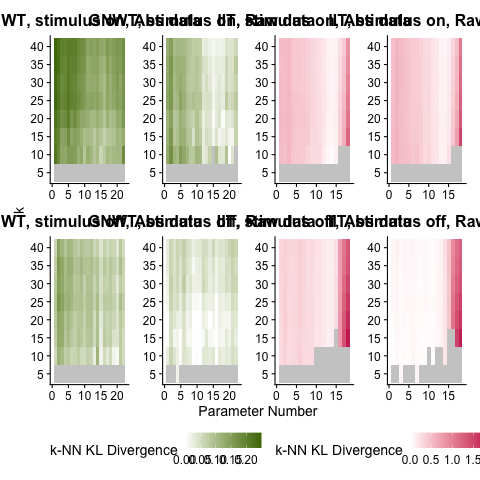

In [12]:
%%R -i all_stats_results

plot_list <- list()
model_color <- list('GNWT'='#4d7700', 'IIT'='#cc3064')

for (stim_type in c('on', 'off')) {
    for (model in c('GNWT', 'IIT')) {
        for (data_type in c("Abs", "Raw")) {
            max_fill <- max(all_stats_results %>% 
                    mutate(KL_Divergence = ifelse(KL_Divergence<0 & !is.na(KL_Divergence) & is.finite(KL_Divergence), 0, KL_Divergence)) %>%
                    filter(is.finite(KL_Divergence), Noise==1, Model==model)  %>%
                    pull(KL_Divergence), na.rm=TRUE
            )

            this_p <- all_stats_results %>% 
                mutate(KL_Divergence = ifelse(KL_Divergence<0 & !is.na(KL_Divergence) & is.finite(KL_Divergence), 0, KL_Divergence)) %>%
                mutate(KL_Divergence_lab = ifelse(is.finite(KL_Divergence), round(KL_Divergence, 2), NA)) %>%
                filter(Model==model, stimulus_presentation==stim_type, Noise==1, Data_Type==data_type) %>% 
                ggplot(data=., mapping=aes(x=Param_Number+1, y=factor(k), fill=KL_Divergence)) +
                geom_tile() +
                scale_fill_gradient(low="white", high=model_color[model], na.value='gray80', limits=c(0, max_fill)) +
                ggtitle(glue("{model}, stimulus {stim_type}, {data_type} data")) +
                theme(legend.position='bottom',
                    plot.title = element_text(hjust=0.5)) +
                labs(fill='k-NN KL Divergence') +
                ylab("k") +
                xlab("Parameter Number")

            plot_list <- rlist::list.append(plot_list, this_p)
        }
    }
}

wrap_plots(plot_list, ncol=4) +
      plot_layout(axis_titles = "collect", guides = "collect")  &
      theme(legend.position = 'bottom')
# ggsave(glue("{plot_dir}/modeling/KL_divergence_vs_k_and_param_grids.svg"), width=12, height=6, units='in', dpi=300)


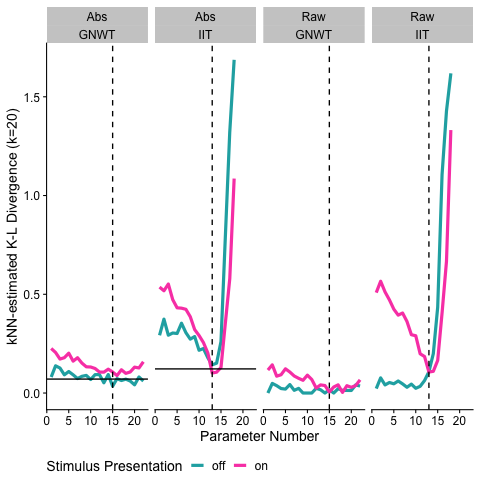

In [13]:
%%R -i all_stats_results,plot_dir

data_to_plot <- all_stats_results %>%
    filter(k==20 & Noise == 1) %>%
    mutate(KL_Divergence = ifelse(KL_Divergence<0, 0, KL_Divergence),
           Param_Number = Param_Number + 1)

data_to_plot %>%
    ggplot(data=., mapping=aes(x=Param_Number, y=KL_Divergence, color=stimulus_presentation)) +
    geom_line(aes(group=stimulus_presentation), linewidth=1.5) +
    geom_vline(data=data_to_plot %>% filter(Model=='GNWT' & Param_Number==15), mapping=aes(xintercept=Param_Number), linetype=2) +
    geom_hline(data=data_to_plot %>% filter(Model=='GNWT' & Param_Number==15 & Data_Type=='Abs'), mapping=aes(yintercept=mean(KL_Divergence))) +
    geom_vline(data=data_to_plot %>% filter(Model=='IIT' & Param_Number==13), mapping=aes(xintercept=Param_Number), linetype=2) +
    geom_hline(data=data_to_plot %>% filter(Model=='IIT' & Param_Number==13 & Data_Type=='Abs'), mapping=aes(yintercept=mean(KL_Divergence))) +
    scale_color_manual(values=c('on'='#fa4db4', 'off'='#1fadb1')) +
    facet_wrap(Data_Type ~ Model, nrow=1) +
    theme(legend.position='bottom') +
    labs(color="Stimulus Presentation") +
    ylab("kNN-estimated K-L Divergence (k=20)") +
    xlab("Parameter Number")
# ggsave(glue("{plot_dir}/modeling/KL_divergence_vs_param_number_k20_raw_data.svg"), width=9, height=3, units='in', dpi=300)

In [14]:
%%R -i all_stats_results

all_stats_results %>%
    filter(k==20 & Noise == 1 & Data_Type == "Abs") %>%
    mutate(KL_Divergence = ifelse(KL_Divergence<0, 0, KL_Divergence),
            Param_Number = Param_Number + 1) %>% 
    group_by(Model, Param_Number) %>% 
    mutate(KL_Divergence_Mean = mean(KL_Divergence)) %>%
    ungroup() %>%
    group_by(Model) %>% 
    filter(KL_Divergence_Mean == min(KL_Divergence_Mean)) %>%
    select(Model, Param_Number, KL_Divergence, KL_Divergence_Mean)

# A tibble: 4 × 4
# Groups:   Model [2]
  Model Param_Number KL_Divergence KL_Divergence_Mean
  <chr>        <dbl>         <dbl>              <dbl>
1 GNWT            15        0.107              0.0706
2 GNWT            15        0.0347             0.0706
3 IIT             13        0.101              0.122 
4 IIT             13        0.143              0.122 


In [15]:
# Find what weights these correspond to
GNWT_optimal_param_weight = np.arange(0.3, 0.85, 0.025)[14] 
IIT_optimal_param_weight = np.arange(0.1, 1.0, 0.05)[12]

print(f"GNWT optimal parameter weight: {GNWT_optimal_param_weight}")
print(f"IIT optimal parameter weight: {IIT_optimal_param_weight}")

GNWT optimal parameter weight: 0.6500000000000004
IIT optimal parameter weight: 0.7000000000000002
